In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_lin42, lifetime_to_temperature_201112
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
from draw_graph import Scatter
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
def figmake():
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['xtick.major.width'] = 1.0
    plt.rcParams['ytick.major.width'] = 1.0
    plt.rcParams['axes.linewidth'] = 1.0
    plt.rcParams["font.size"] = 20
    plt.figure(figsize = (6, 6))

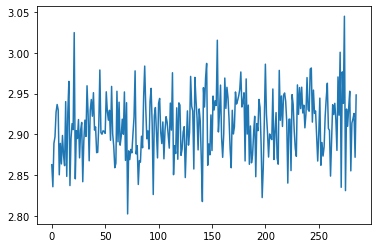

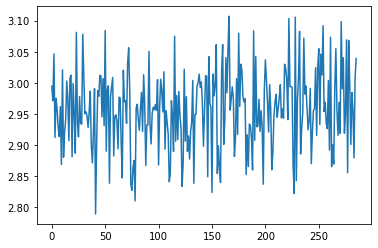

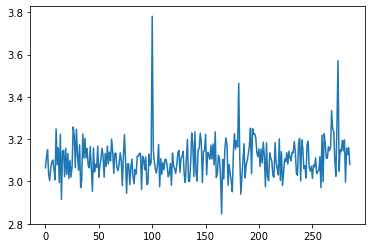

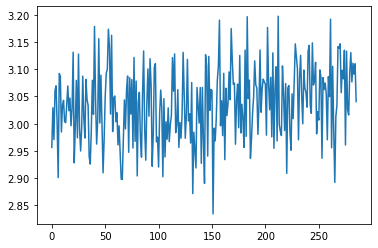

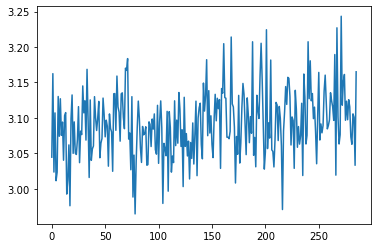

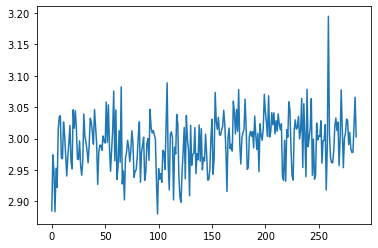

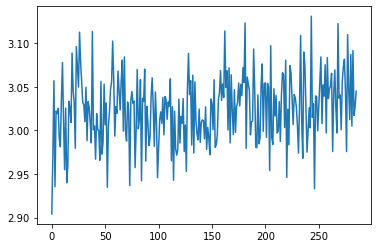

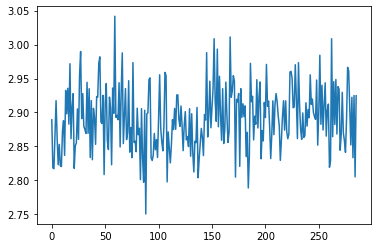

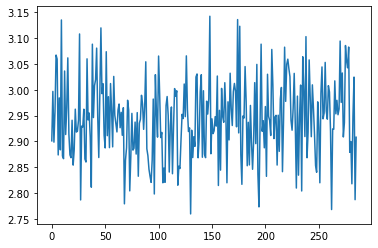

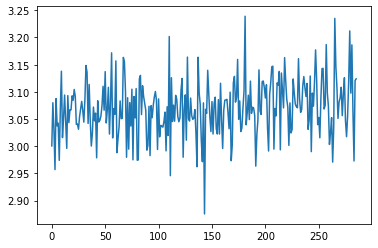

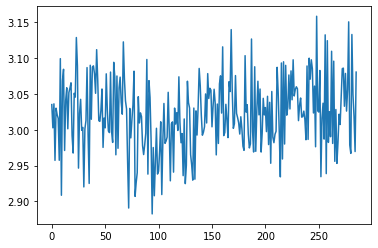

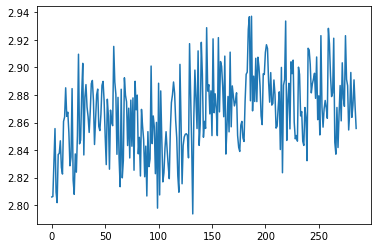

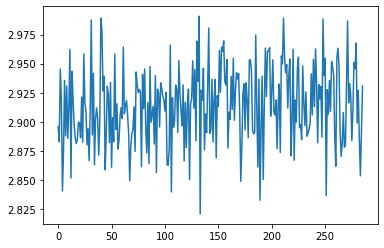

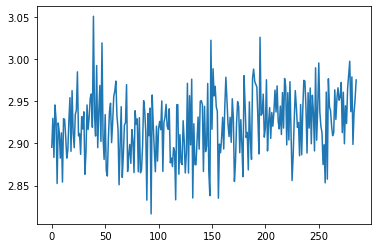

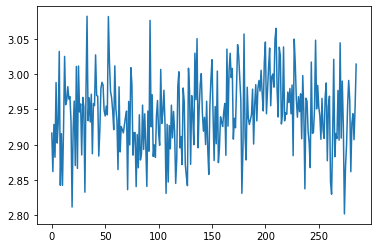

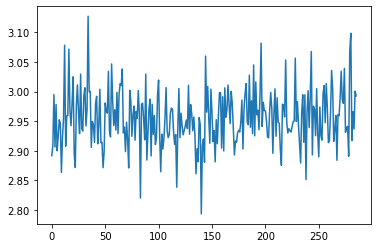

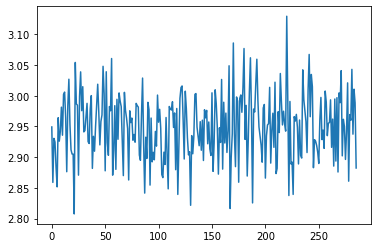

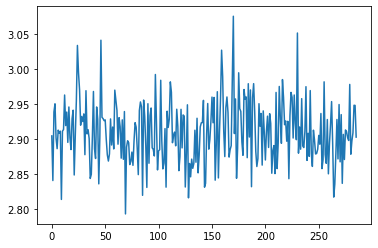

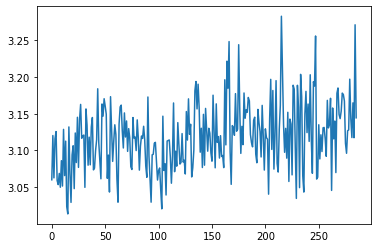

In [3]:
file_path = glob.glob('./CP/25090?_IRheating_100mW_5sec_lin25/cell??.csv')
file_path.sort()
data_set_CP = pd.DataFrame()
average_lin25 = 0

for path in file_path:
    df = pd.read_csv(path, sep = '\t')
    tauFAST_trace = np.array(df.iloc[1:, 1], dtype = 'float32')
    average_lin25 += tauFAST_trace
    plt.plot(tauFAST_trace)
    plt.show()
    data_set_CP = pd.concat([data_set_CP, pd.DataFrame(tauFAST_trace)], axis = 1)

average_lin25 = average_lin25/len(file_path)

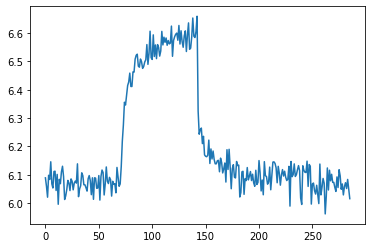

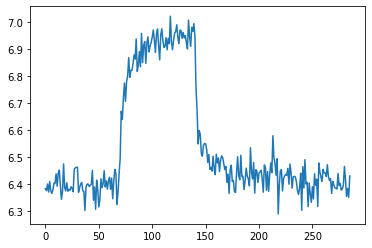

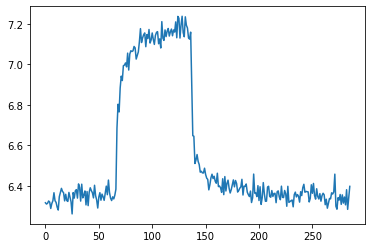

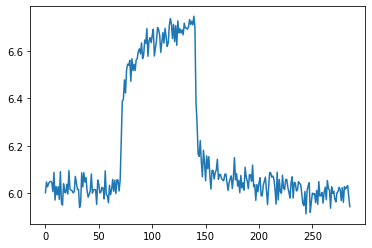

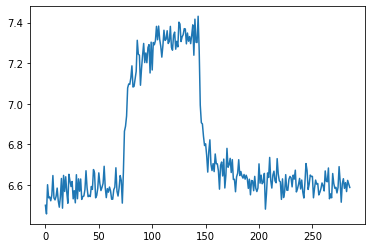

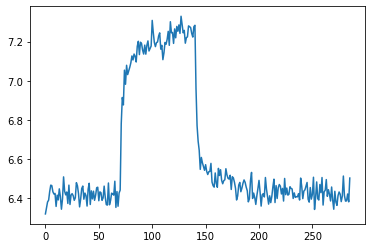

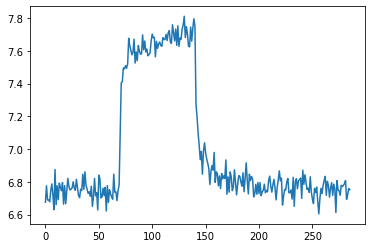

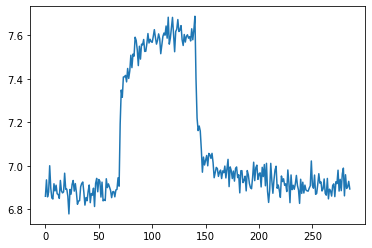

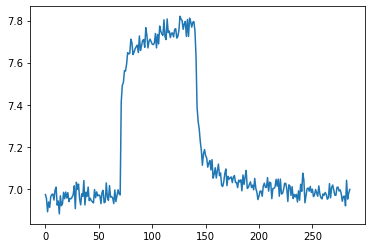

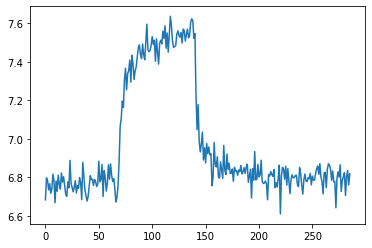

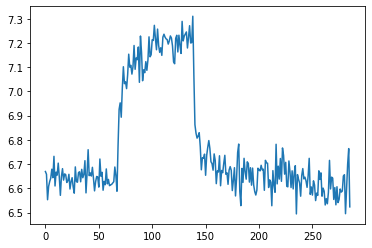

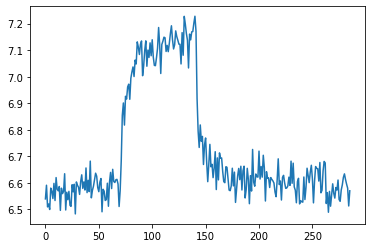

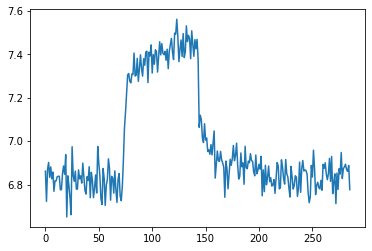

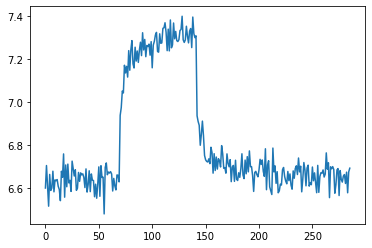

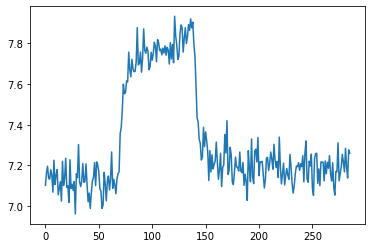

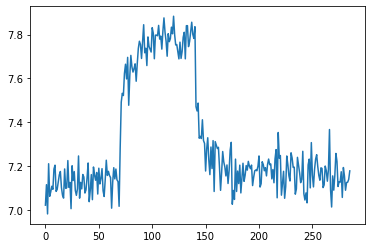

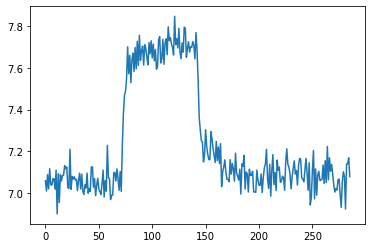

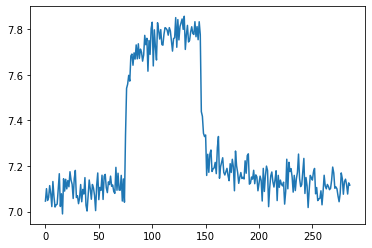

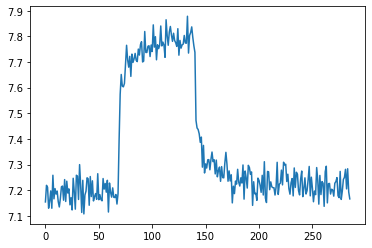

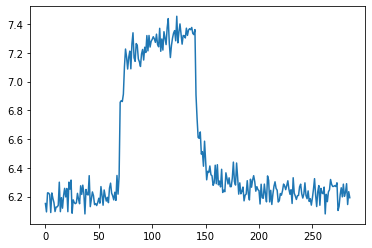

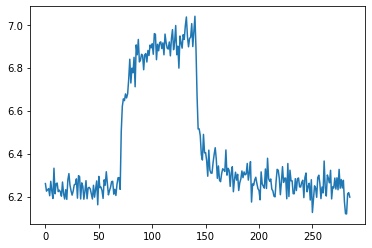

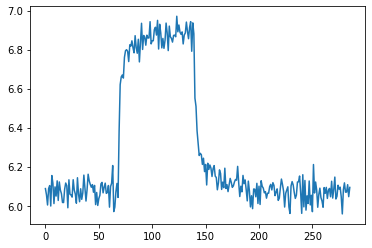

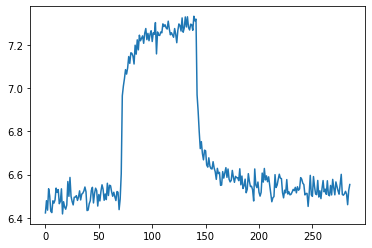

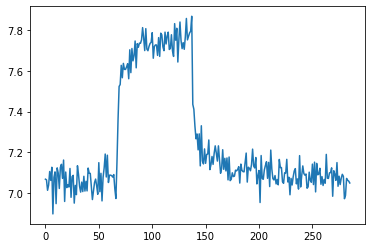

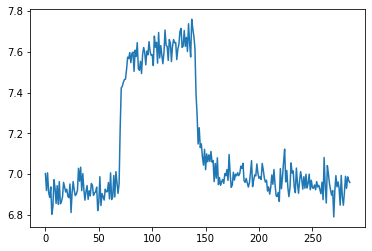

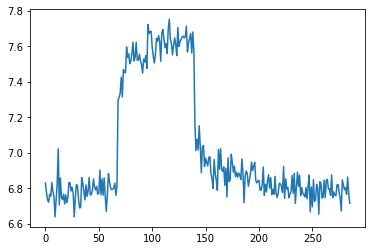

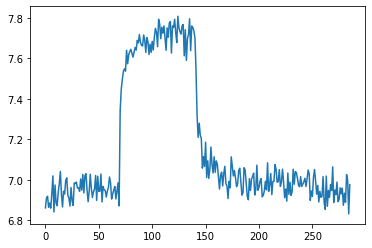

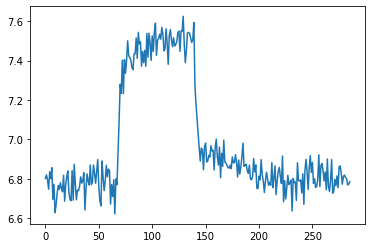

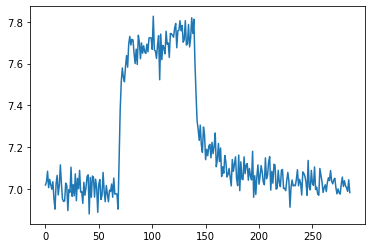

In [4]:
file_path = glob.glob('./FPT/*/*/cell??.csv')
file_path.sort()
data_set_FPT = pd.DataFrame()
average_lin22 = 0

for path in file_path:
    df = pd.read_csv(path, sep = '\t')
    tauFAST_trace = np.array(df.iloc[1:, 1], dtype = 'float32')
    average_lin22 += tauFAST_trace
    plt.plot(tauFAST_trace)
    plt.show()
    data_set_FPT = pd.concat([data_set_FPT, pd.DataFrame(tauFAST_trace)], axis = 1)

average_lin22 = average_lin22/len(file_path)

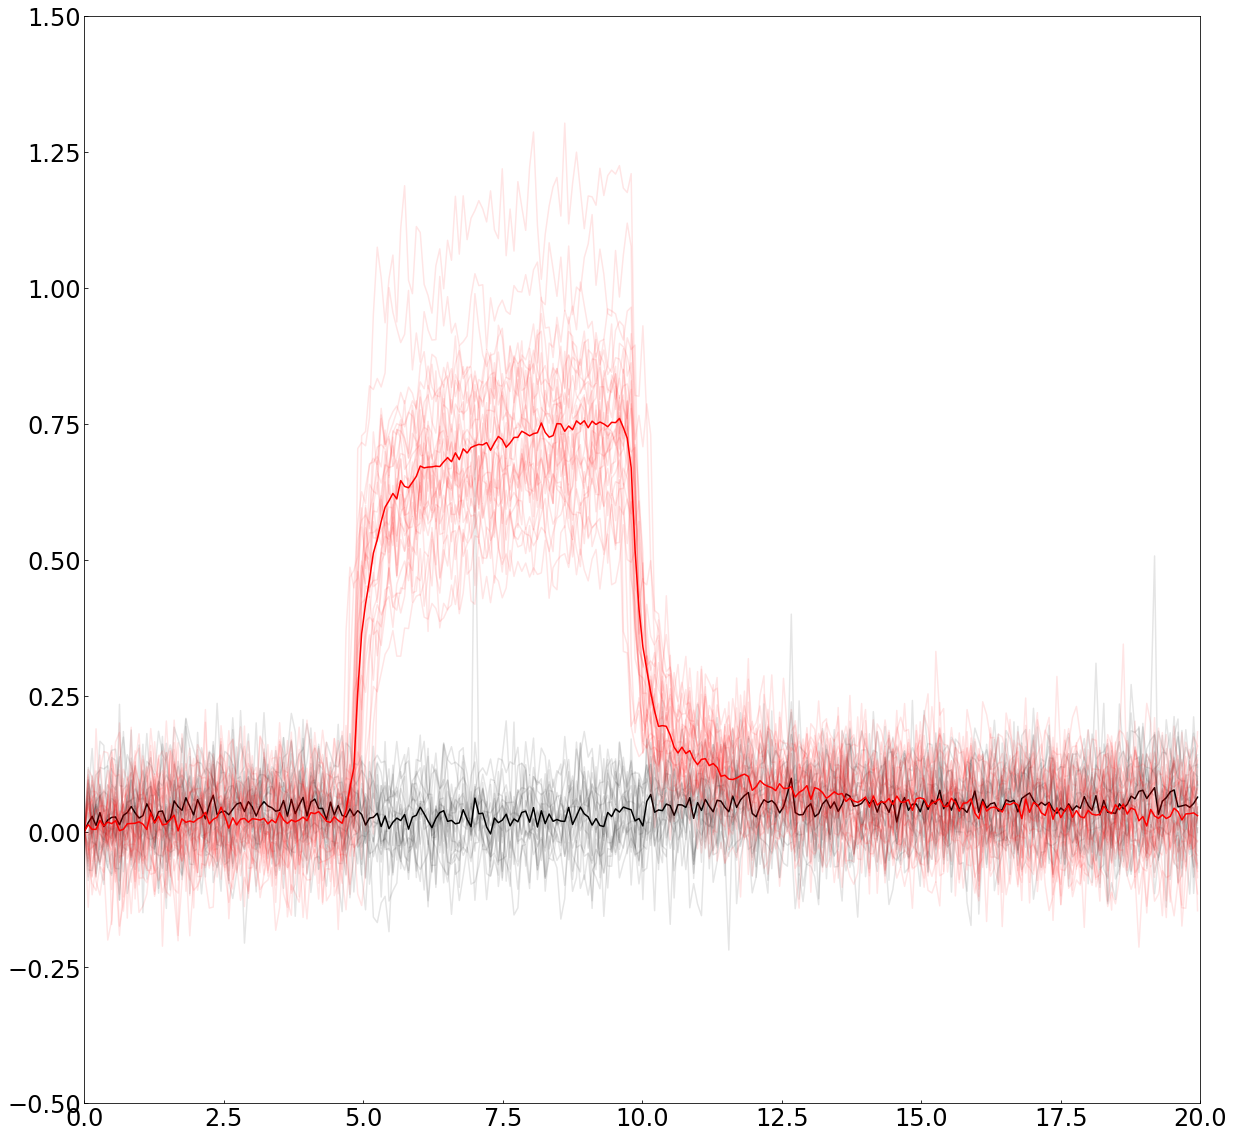

In [5]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time = [i*0.07 for i in range(len(average_lin25))]
plt.plot(time, average_lin25-average_lin25[0], color = 'black')
plt.plot(time, data_set_CP - data_set_CP.iloc[0, :], color = 'black', alpha = 0.1)
plt.plot(time, average_lin22-average_lin22[0], color = 'red')
plt.plot(time, data_set_FPT - data_set_FPT.iloc[0, :], color = 'red', alpha = 0.1)
plt.ylim(-0.5, 1.5)
plt.xlim(0, 20)
plt.show()


#pdfのセーブ
pp = PdfPages('./FPT_CP_tauFAST_trace.pdf')
pp.savefig(fig)
pp.close()

In [6]:
data_set_CP.to_csv('CP.csv')
data_set_FPT.to_csv('FPT.csv')